In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 3)

In [8]:
df = pd.read_csv("../transaction_data.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [23]:
#understend csv
df.shape
df.columns
df.info()
df.describe()
df.tail()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1947621,177,CASH_OUT,147857.04,C1952151451,0.00,0.00,C1078884197,12921761.97,13069619.01,0,0
342359,16,CASH_IN,61815.75,C1476617328,566417.47,628233.22,C1817874146,2031539.43,1969723.68,0,0
144334,11,CASH_OUT,231921.55,C2034721125,44583.94,0.00,C1891465089,836123.45,1264155.95,0,0
5840602,402,CASH_OUT,52170.61,C1362398670,0.00,0.00,C175041411,7583785.61,7635956.22,0,0
4818061,346,PAYMENT,5309.12,C757143265,0.00,0.00,M481912628,0.00,0.00,0,0


In [21]:
#find missing value
df.isnull().sum()
#(df.isnull().sum() / len(df)) * 100  (for %)
df.duplicated().sum()

np.int64(0)

In [22]:
# fraud detection
df["isFraud"].value_counts()
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [25]:
#Distributing numerical and categorical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Categorical Columns: ['type', 'nameOrig', 'nameDest']


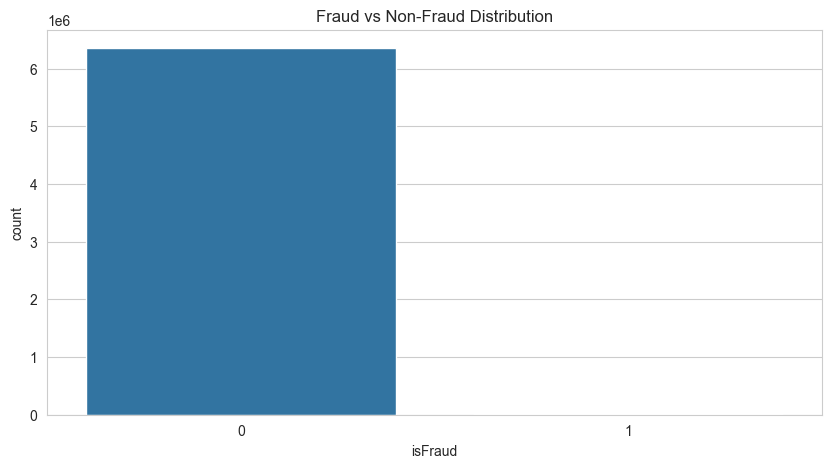

In [26]:
# plot
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

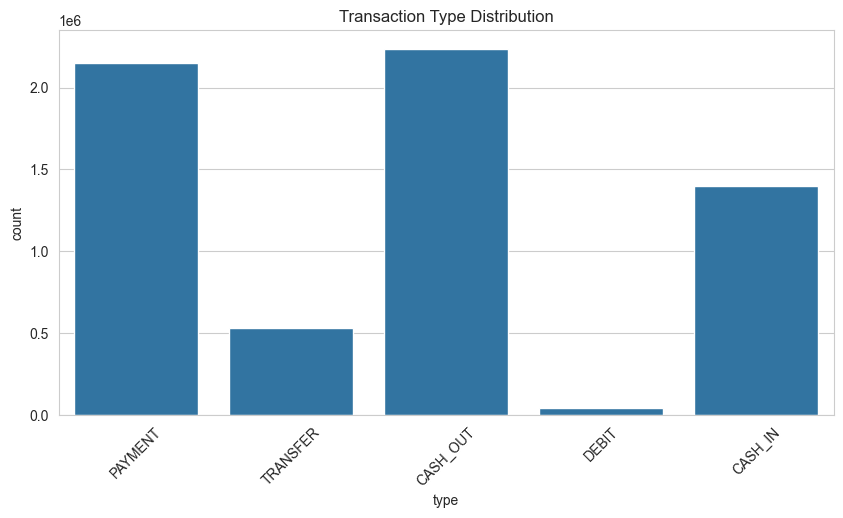

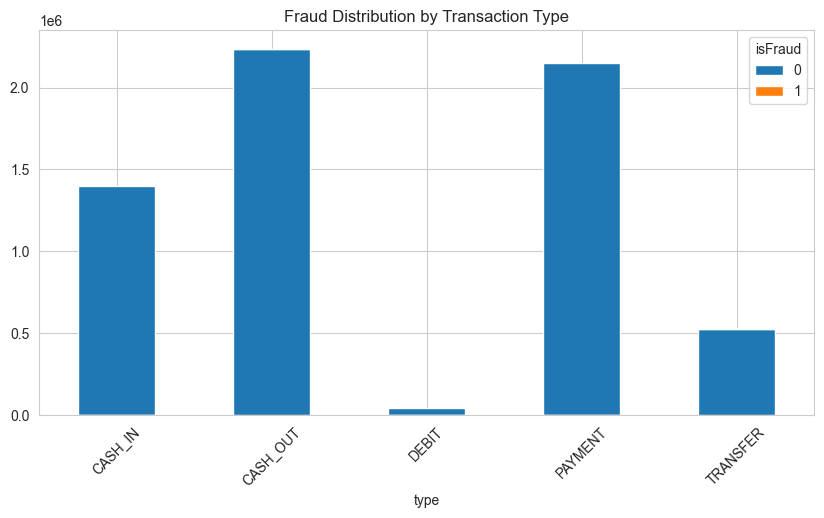

In [30]:
# Transaction Type Distribution
sns.countplot(x="type", data=df)
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.show()

# fraud
fraud_by_type = pd.crosstab(df["type"], df["isFraud"])
fraud_by_type.plot(kind="bar", stacked=True)
plt.title("Fraud Distribution by Transaction Type")
plt.xticks(rotation=45)
plt.show()

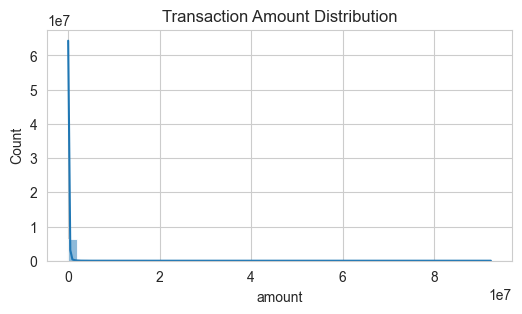

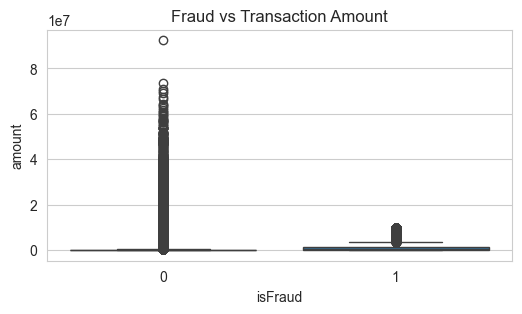

In [35]:
# amount distribution
sns.histplot(df["amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

# amount vs fraud
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()